In [1]:
from emnist import list_datasets
import numpy as np
import pandas as pd
import itertools
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2 as cv
from matplotlib import pyplot as plt
#list_datasets()


Shape of train_images:  (112800, 28, 28)
Image shape: (28, 28)
Max = 255   Min = 0
27


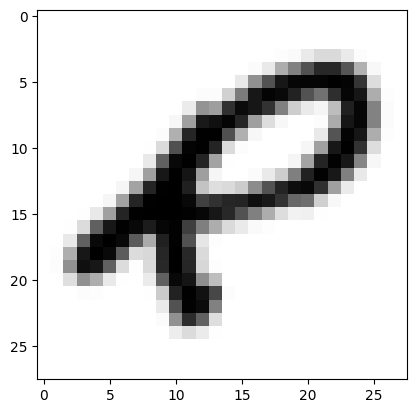

In [40]:
from emnist import extract_training_samples
from emnist import extract_test_samples

x_train, y_train = extract_training_samples('balanced')
x_test, y_test = extract_test_samples('balanced')
# print dataset shape
print("Shape of train_images: ", x_train.shape)
# and the shape of an image
print("Image shape:", x_train[0].shape)

# print the range of the values
print("Max =", np.max(x_train),"  Min =", np.min(x_train))

index = 5434 #exaple

plt.imshow(x_train[index], cmap=plt.cm.binary)
print(y_train[index])

In [42]:
ALL_LABELS = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 
          'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
          'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']

SELECTED_LABELS = ['B', 'b', 'G', 'g', 'T', 't', 'Y']

def filterDataset(X_data, y_data):
    assert y_data.dtype == np.uint8
    classes = ALL_LABELS
    new_data_size = 0
    for recordIndex in range(0, y_data.shape[0]):
        currentLabel = classes[y_data[recordIndex]]
        if currentLabel in SELECTED_LABELS:
            new_data_size += 1

    new_X_data = np.zeros((new_data_size, 28, 28), dtype = X_data.dtype)
    new_y_data = np.zeros((new_data_size,), dtype = np.uint8)

    new_data_index = 0
    for recordIndex in range(0, y_data.shape[0]):
        currentLabel = classes[y_data[recordIndex]]

        if currentLabel not in SELECTED_LABELS:
            continue
        
        new_X_data[new_data_index] = X_data[recordIndex]
        new_y_data[new_data_index] = SELECTED_LABELS.index(currentLabel)
        new_data_index += 1
    
    assert new_data_index == new_X_data.shape[0]
    return (new_X_data, new_y_data)

In [43]:
(x_train_filter, y_train_filter) = filterDataset(x_train, y_train)
(x_test_filter, y_test_filter) = filterDataset(x_test, y_test)

x_train_filter = x_train_filter / np.max(x_train_filter)
x_test_filter = x_test_filter / np.max(x_test_filter)


x_train_flat = x_train_filter.reshape(len(x_train_filter), (28 * 28))
x_test_flat = x_test_filter.reshape(len(x_test_filter), (28 * 28))

b


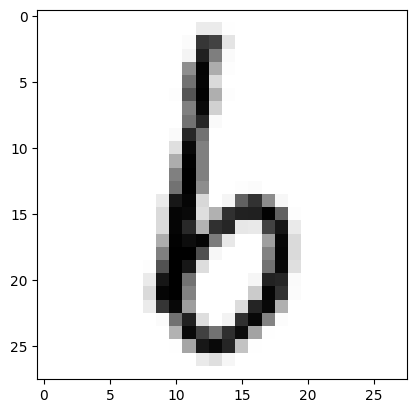

In [44]:
index = 110

plt.imshow(x_train_filter[index], cmap=plt.cm.binary)
print(SELECTED_LABELS[y_train_filter[index]])

In [ ]:
from pathlib import Path

modelPath = "models/opt_pretrained_model.keras"

my_file = Path(modelPath)
if my_file.exists():
    model = keras.models.load_model(modelPath)
else:
    model = keras.Sequential([
        layers.Dense(256, input_shape=(784,), activation='relu'),
        layers.Dense(64, activation='sigmoid'),
        layers.Dense(16, activation='hard_sigmoid'),
        layers.Dense(len(SELECTED_LABELS), activation='softmax'),
    ])

    tb_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/", histogram_freq=1)

    model.compile(
        optimizer = 'AdamW',
        loss = 'sparse_categorical_crossentropy',
        metrics = ['accuracy']
    )

    model.fit(x_train_flat, y_train_filter, epochs=20, callbacks=[tb_callback])

In [45]:
# Spazio di ricerca
param_grid = {
    'hidden_layers': [
        [256, 64],
        [256, 128, 64],
        [512, 256, 64, 16],
    ],
    'activations': ['relu', 'tanh', 'sigmoid'],
    'optimizer': ['adam', 'adamw', 'sgd'],
    'dropout_rate': [0.0, 0.2, 0.3],
}

def build_model(hidden_layers, activation, optimizer, dropout_rate):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(len(SELECTED_LABELS), activation='softmax'))
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

results = []

combos = list(itertools.product(
    param_grid['hidden_layers'],
    param_grid['activations'],
    param_grid['optimizer'],
    param_grid['dropout_rate'],
))

for layers_cfg, act, opt, dr in combos:
    model = build_model(layers_cfg, act, opt, dr)
    history = model.fit(
        x_train_flat, y_train_filter,
        epochs=15,
        validation_split=0.1,
        verbose=0
    )
    _, test_acc = model.evaluate(x_test_flat, y_test_filter, verbose=0)
    val_acc = max(history.history['val_accuracy'])
    
    results.append({
        'layers': str(layers_cfg),
        'activation': act,
        'optimizer': opt,
        'dropout': dr,
        'val_accuracy': round(val_acc, 4),
        'test_accuracy': round(test_acc, 4),
        'params': model.count_params(),
    })
    print(f"Done: {layers_cfg} | {act} | {opt} | dr={dr} → test={test_acc:.4f}")

df = pd.DataFrame(results).sort_values('test_accuracy', ascending=False)
print(df.head(10))
df.to_csv('grid_search_results.csv', index=False)

Done: [256, 64] | relu | adam | dr=0.0 → test=0.9411
Done: [256, 64] | relu | adam | dr=0.2 → test=0.9489
Done: [256, 64] | relu | adam | dr=0.3 → test=0.9486
Done: [256, 64] | relu | adamw | dr=0.0 → test=0.9346
Done: [256, 64] | relu | adamw | dr=0.2 → test=0.9475
Done: [256, 64] | relu | adamw | dr=0.3 → test=0.9389
Done: [256, 64] | relu | sgd | dr=0.0 → test=0.9264
Done: [256, 64] | relu | sgd | dr=0.2 → test=0.9239
Done: [256, 64] | relu | sgd | dr=0.3 → test=0.9221
Done: [256, 64] | tanh | adam | dr=0.0 → test=0.9407
Done: [256, 64] | tanh | adam | dr=0.2 → test=0.9436
Done: [256, 64] | tanh | adam | dr=0.3 → test=0.9418
Done: [256, 64] | tanh | adamw | dr=0.0 → test=0.9361
Done: [256, 64] | tanh | adamw | dr=0.2 → test=0.9318
Done: [256, 64] | tanh | adamw | dr=0.3 → test=0.9414
Done: [256, 64] | tanh | sgd | dr=0.0 → test=0.9096
Done: [256, 64] | tanh | sgd | dr=0.2 → test=0.9007
Done: [256, 64] | tanh | sgd | dr=0.3 → test=0.8964
Done: [256, 64] | sigmoid | adam | dr=0.0 → te

In [46]:
# Miglior configurazione
print(df.iloc[0])

# Effetto dell'activation function (media per gruppo)
print(df.groupby('activation')['test_accuracy'].mean().sort_values(ascending=False))
print(df.groupby('optimizer')['test_accuracy'].mean().sort_values(ascending=False))
print(df.groupby('dropout')['test_accuracy'].mean().sort_values(ascending=False))

layers           [256, 64]
activation            relu
optimizer             adam
dropout                0.2
val_accuracy        0.9524
test_accuracy       0.9489
params              217863
Name: 1, dtype: object
activation
relu       0.937896
tanh       0.926374
sigmoid    0.806344
Name: test_accuracy, dtype: float64
optimizer
adam     0.940870
adamw    0.939956
sgd      0.789789
Name: test_accuracy, dtype: float64
dropout
0.0    0.892978
0.2    0.892293
0.3    0.885344
Name: test_accuracy, dtype: float64


In [47]:
import keras_tuner as kt

def model_builder(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))
    for i in range(hp.Int('num_layers', 1, 4)):
        model.add(layers.Dense(
            units=hp.Choice(f'units_{i}', [32, 64, 128, 256, 512]),
            activation=hp.Choice('activation', ['relu', 'tanh'])
        ))
    model.add(layers.Dense(len(SELECTED_LABELS), activation='softmax'))
    model.compile(
        optimizer=hp.Choice('optimizer', ['adam', 'adamw']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(model_builder, objective='val_accuracy', max_trials=30)
tuner.search(x_train_flat, y_train_filter, epochs=15, validation_split=0.1)
print(tuner.results_summary())

Trial 30 Complete [00h 00m 16s]
val_accuracy: 0.9488095045089722

Best val_accuracy So Far: 0.9541666507720947
Total elapsed time: 00h 08m 44s
Results summary
Results in .\untitled_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 27 summary
Hyperparameters:
num_layers: 2
units_0: 512
activation: relu
optimizer: adam
units_1: 512
units_2: 256
units_3: 64
Score: 0.9541666507720947

Trial 01 summary
Hyperparameters:
num_layers: 2
units_0: 512
activation: relu
optimizer: adamw
units_1: 32
units_2: 128
units_3: 512
Score: 0.9511904716491699

Trial 04 summary
Hyperparameters:
num_layers: 2
units_0: 512
activation: tanh
optimizer: adam
units_1: 32
units_2: 256
units_3: 32
Score: 0.9511904716491699

Trial 03 summary
Hyperparameters:
num_layers: 3
units_0: 256
activation: relu
optimizer: adamw
units_1: 256
units_2: 256
units_3: 64
Score: 0.9505952596664429

Trial 12 summary
Hyperparameters:
num_layers: 1
units_0: 256
activation: tanh
optimizer: adamw
units_1

In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs/

In [35]:
result = model.evaluate(x_test_flat, y_test_filter)

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9450 - loss: 0.2748  


In [36]:
model.save(modelPath)

In [32]:
y_predicted = model.predict(x_test_flat)


88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [33]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]

In [34]:
cm = tf.math.confusion_matrix(labels=y_test_filter, predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(7, 7), dtype=int32, numpy=
array([[386,   2,   1,   5,   6,   0,   0],
       [  9, 383,   1,   1,   2,   0,   4],
       [  0,   0, 382,   2,  10,   0,   6],
       [ 10,   5,   0, 373,  12,   0,   0],
       [  8,   1,  15,  10, 364,   0,   2],
       [  0,   0,   3,   0,   3, 378,  16],
       [  2,   4,   0,   0,   2,  21, 371]])>

In [4]:


img = cv.imread('fototest/imgG.jpeg')

def rescaleFrame(frame, dimensions=None):
    if(dimensions != None):
        return cv.resize(frame, dimensions, interpolation=cv.INTER_AREA)
    
    scale = 0.60
    width = int(frame.shape[1] * scale)
    height = int(frame.shape[0] * scale)

    dimensions = (width, height)
    return cv.resize(frame, dimensions, interpolation=cv.INTER_AREA)

#cv.imshow('Test', rescaleFrame(img)) 

rescaledImg = rescaleFrame(img, (300, 300))

blank = np.zeros(rescaledImg.shape, dtype='uint8')

gray = cv.cvtColor(rescaledImg, cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)
cv.imshow("Thresh", thresh)

contours, hierarchies = cv.findContours(thresh, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
print(len(contours))

cv.drawContours(blank, contours, -1, (0, 0, 255), 1)
cv.imshow("Contours Drawn", blank)
#print(hierarchies)
#print(contours)

cv.waitKey(0)

254


-1

In [8]:
# ─── CONFIG ───────────────────────────────────────────────────────────────────
MODEL_PATH = "models/adv_pretrained_model_adamw.keras"          # il tuo modello salvato

IMG_SIZE = 28                               # dimensione attesa dal modello (EMNIST = 28x28)
EMPTY_THRESHOLD = 0.02                      # soglia di "cella vuota" (varianza pixel)

# ─── LOAD MODEL ───────────────────────────────────────────────────────────────
model = keras.models.load_model(MODEL_PATH)


def preprocess_cell(cell_img):
    """Prepara una singola cella per il modello."""
    gray = cv.cvtColor(cell_img, cv.COLOR_BGR2GRAY) if len(cell_img.shape) == 3 else cell_img
    resized = cv.resize(gray, (IMG_SIZE, IMG_SIZE), interpolation=cv.INTER_AREA)
    # Binarizzazione adattiva per resistere a variazioni di illuminazione
    _, thresh = cv.threshold(resized, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
    normalized = thresh.astype(np.float32) / 255.0
    return normalized.reshape(1, IMG_SIZE * IMG_SIZE)


def is_cell_empty(cell_img):
    """Rileva se una cella è vuota basandosi sulla varianza dei pixel."""
    gray = cv.cvtColor(cell_img, cv.COLOR_BGR2GRAY) if len(cell_img.shape) == 3 else cell_img
    return np.var(gray) / (255.0 ** 2) < EMPTY_THRESHOLD


def order_points(pts):
    """Ordina 4 punti: top-left, top-right, bottom-right, bottom-left."""
    pts = pts.reshape(4, 2).astype(np.float32)
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    return np.array([
        pts[np.argmin(s)],    # top-left
        pts[np.argmin(diff)], # top-right
        pts[np.argmax(s)],    # bottom-right
        pts[np.argmax(diff)]  # bottom-left
    ], dtype=np.float32)


def detect_grid_contour(img):
    """
    Trova il rettangolo della griglia nell'immagine.
    Ritorna i 4 corner ordinati oppure None se non trovato.
    """
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    blurred = cv.GaussianBlur(gray, (5, 5), 0)
    edges = cv.Canny(blurred, 50, 150)

    # Dilata per chiudere eventuali gap nei bordi
    kernel = np.ones((3, 3), np.uint8)
    edges = cv.dilate(edges, kernel, iterations=1)

    contours, _ = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv.contourArea, reverse=True)

    for cnt in contours[:10]:
        peri = cv.arcLength(cnt, True)
        approx = cv.approxPolyDP(cnt, 0.02 * peri, True)
        if len(approx) == 4 and cv.contourArea(approx) > 0.05 * img.shape[0] * img.shape[1]:
            return order_points(approx)
    return None


def warp_grid(img, corners):
    """Applica trasformazione prospettica per raddrizzare la griglia."""
    tl, tr, br, bl = corners
    w = int(max(np.linalg.norm(br - bl), np.linalg.norm(tr - tl)))
    h = int(max(np.linalg.norm(tr - br), np.linalg.norm(tl - bl)))

    dst = np.array([[0, 0], [w-1, 0], [w-1, h-1], [0, h-1]], dtype=np.float32)
    M = cv.getPerspectiveTransform(corners, dst)
    return cv.warpPerspective(img, M, (w, h)), w, h


def detect_grid_lines(warped_img):
    """
    Trova linee orizzontali e verticali per determinare righe e colonne.
    Ritorna (row_splits, col_splits) come liste di coordinate y e x.
    """
    gray = cv.cvtColor(warped_img, cv.COLOR_BGR2GRAY)
    _, thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

    h, w = thresh.shape

    # Proiezione orizzontale: somma pixel per riga → picchi = linee orizzontali
    h_proj = np.sum(thresh, axis=1) / 255.0
    v_proj = np.sum(thresh, axis=0) / 255.0

    def find_splits(projection, size, min_frac=0.3):
        """Trova posizioni dove la linea copre almeno min_frac della dimensione."""
        threshold = size * min_frac
        is_line = projection > threshold
        splits = []
        in_line = False
        start = 0
        for i, val in enumerate(is_line):
            if val and not in_line:
                in_line = True
                start = i
            elif not val and in_line:
                in_line = False
                splits.append((start + i) // 2)  # centro della linea
        return splits

    row_lines = find_splits(h_proj, w)
    col_lines = find_splits(v_proj, h)

    # Aggiungi bordi se non presenti
    if not row_lines or row_lines[0] > h * 0.05:
        row_lines = [0] + row_lines
    if not row_lines or row_lines[-1] < h * 0.95:
        row_lines = row_lines + [h]
    if not col_lines or col_lines[0] > w * 0.05:
        col_lines = [0] + col_lines
    if not col_lines or col_lines[-1] < w * 0.95:
        col_lines = col_lines + [w]

    return row_lines, col_lines


def extract_and_classify(warped_img, row_splits, col_splits):
    """
    Estrae ogni cella e la classifica.
    Ritorna la matrice di caratteri (stringa) e la matrice di confidenze.
    """
    n_rows = len(row_splits) - 1
    n_cols = len(col_splits) - 1
    matrix = []
    confidence_matrix = []
    padding = 3  # pixel di margine da togliere per evitare i bordi della griglia

    for r in range(n_rows):
        row_chars = []
        row_conf = []
        y1, y2 = row_splits[r] + padding, row_splits[r+1] - padding
        for c in range(n_cols):
            x1, x2 = col_splits[c] + padding, col_splits[c+1] - padding
            cell = warped_img[y1:y2, x1:x2]

            if cell.size == 0 or is_cell_empty(cell):
                row_chars.append(' ')
                row_conf.append(0.0)
            else:
                flat = preprocess_cell(cell)
                probs = model.predict(flat, verbose=0)[0]
                idx = np.argmax(probs)
                row_chars.append(SELECTED_LABELS[idx])
                row_conf.append(float(probs[idx]))

        matrix.append(row_chars)
        confidence_matrix.append(row_conf)

    return matrix, confidence_matrix


def process_image(image_path):
    """
    Pipeline completa: immagine → matrice di caratteri.
    Ritorna (char_matrix, conf_matrix, debug_img).
    """
    img = cv.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Impossibile aprire: {image_path}")

    # 1. Trova la griglia
    corners = detect_grid_contour(img)
    if corners is None:
        raise ValueError("Nessuna griglia trovata nell'immagine.")

    # 2. Raddrizza la prospettiva
    warped, w, h = warp_grid(img, corners)

    # 3. Trova le linee interne
    row_splits, col_splits = detect_grid_lines(warped)
    print(f"  Griglia rilevata: {len(row_splits)-1} righe × {len(col_splits)-1} colonne")

    # 4. Classifica le celle
    char_matrix, conf_matrix = extract_and_classify(warped, row_splits, col_splits)

    # 5. Immagine di debug (griglia annotata)
    debug = warped.copy()
    for y in row_splits:
        cv.line(debug, (0, y), (w, y), (0, 255, 0), 1)
    for x in col_splits:
        cv.line(debug, (x, 0), (x, h), (0, 255, 0), 1)
    for r, row in enumerate(char_matrix):
        for c, ch in enumerate(row):
            if ch != ' ':
                cy = (row_splits[r] + row_splits[r+1]) // 2
                cx = (col_splits[c] + col_splits[c+1]) // 2
                cv.putText(debug, ch, (cx-5, cy+5),
                            cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    return char_matrix, conf_matrix, debug


def print_matrix(char_matrix, conf_matrix=None):
    """Stampa la matrice in modo leggibile."""
    for r, row in enumerate(char_matrix):
        line = ' '.join(row)
        print(line)
        if conf_matrix:
            confs = ' '.join(f"{c:.2f}" for c in conf_matrix[r])
            print(f"  conf: [{confs}]")



path = "fototest/img1.jpeg"
    
print(f"\n{'─'*50}")
print(f"File: {path}")
try:
    char_matrix, conf_matrix, debug_img = process_image(path)
    print_matrix(char_matrix, conf_matrix)

    out_path = Path(path).stem + "_debug.png"
    cv.imwrite(out_path, debug_img)
    print(f"  Debug salvato: {out_path}")

    # Matrice come numpy array di stringhe
    np_matrix = np.array(char_matrix)
    print(f"  Shape matrice: {np_matrix.shape}")

except Exception as e:
    print(f"  ERRORE: {e}")


──────────────────────────────────────────────────
File: fototest/img1.jpeg
  ERRORE: Nessuna griglia trovata nell'immagine.
